# Idea

Get more insight into the active features, lags and coefficients by using SHAP

## Naming Conventions with example:

Belong to X:
- Feature: *|avg B|* (refers to a measured physical parameter)
- Lag: *|avg B|_lag_1* (refers to all columns in X)

Belong to y:
- Target: *y_step_1*

Belong to the Model:
- Coefficient: each coefficient belongs to one Lag and a target

In [1]:
import os
# os.nice(19)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib
import re
import shap

# Settings

In [2]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
start_time = '2024-07-24 00:00:00'
end_time = '2024-12-31 12:59:00'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
target = 'trend'
m = 15

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
GFOC_data = GFOC_data.loc[start_time:end_time]
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X_test = pd.read_parquet(X_file)
X_test = X_test.loc[start_time:end_time]
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y_test = pd.read_parquet(y_file)
y_test = y_test.loc[start_time:end_time]
print(f"✅ Successfully loaded features X_test with shape: {X_test.shape} and target y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (46236, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X_test with shape: (46224, 538) and target y_test with shape: (46224, 48)


# Load Models

In [4]:
MODEL_DIR = find_repo_root() / Path("Analysis/modeling/tscv_models")

pipelines = {}

# pattern:
# tscv_MultiTaskLasso_{target}_pipeline_{alpha}_{number}.pkl
pattern = re.compile(
    r'tscv_MultiTaskLasso_'
    r'(?P<target>.+?)_pipeline_'
    r'(?P<alpha>\d+p\d+)_'
    r'(?P<number>[A-Za-z0-9]+)\.pkl'
)

# --- collect and sort files deterministically ---
pkl_files = []

for pkl_file in MODEL_DIR.glob("*.pkl"):
    match = pattern.match(pkl_file.name)
    if not match:
        continue

    target = match.group("target")
    alpha = float(match.group("alpha").replace("p", "."))
    number = match.group("number")  # string, e.g. "1", "1i"

    pkl_files.append((target, number, alpha, pkl_file))

# sort by target, number, alpha
pkl_files.sort(key=lambda x: (x[0], x[1], x[2]))

# --- load pipelines ---
for target, number, alpha, pkl_file in pkl_files:
    pipelines.setdefault(target, {}).setdefault(number, {})[alpha] = (
joblib.load(pkl_file)
    )

print(f"✅ Successfully loaded pipelines for targets: {list(pipelines.keys())}")

✅ Successfully loaded pipelines for targets: ['trend']


Remove unwanted pipelines (depend on the sampling rate)

In [5]:
# remove pipeline with number '14' if exists
if '14' in pipelines.get(target, {}):
    del pipelines[target]['14']
    print("Removed pipeline with number '14' due to known issues.")

Removed pipeline with number '14' due to known issues.


Show all loaded pipelines

In [6]:
for target in pipelines.keys():
    print(f"Target: {target}")
    for number in pipelines[target].keys():
        alphas = list(pipelines[target][number].keys())
        print(f"  Number: {number}, Alphas: {alphas}")

Target: trend
  Number: 1, Alphas: [0.05, 0.075, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]
  Number: 1i, Alphas: [0.05, 0.1]
  Number: 3, Alphas: [0.05, 0.1, 0.25, 0.5, 1.0, 5.0]
  Number: 4, Alphas: [0.02, 0.05, 0.1, 0.5, 1.0, 5.0]
  Number: 4i, Alphas: [0.1, 0.5]


# 1. Check Coefficients for one Pipeline

select pipeline

In [7]:
Alpha = 0.1
target = 'trend'
number = '3'

#
pipeline = pipelines[target][number][Alpha]
print(f"✅ Using pipeline for target '{target}', number '{number}', alpha {Alpha}")

✅ Using pipeline for target 'trend', number '3', alpha 0.1


# SHAP

## Step 1: inspect the pipeline

In [9]:
print(pipeline.named_steps)

{'scaler': StandardScaler(), 'lasso': MultiTaskLasso(alpha=0.1, max_iter=20000, selection='random', warm_start=True)}


## Step 2: extract transformed features and model coefficients

Choose Horizon to explain

In [10]:
horizon_idx = 0
horizon_name =y_test.columns[horizon_idx]
print(f"✅ Analyzing SHAP values for horizon '{horizon_name}'")

✅ Analyzing SHAP values for horizon 'y_step_1'


Identify pipeline parts

In [11]:
print(pipeline.named_steps)

# replace these names if needed after inspecting pipeline.named_steps
preprocessor_name = list(pipeline.named_steps.keys())[:-1][0]
model_name = list(pipeline.named_steps.keys())[-1]

preprocessor = pipeline.named_steps[preprocessor_name]
model = pipeline.named_steps[model_name]

print("Preprocessor:", preprocessor_name)
print("Model:", model_name)

{'scaler': StandardScaler(), 'lasso': MultiTaskLasso(alpha=0.1, max_iter=20000, selection='random', warm_start=True)}
Preprocessor: scaler
Model: lasso


Transform X

In [12]:
X_trans = preprocessor.transform(X_test)

# convert to dense if sparse
if hasattr(X_trans, "toarray"):
    X_trans = X_trans.toarray()

X_trans = np.asarray(X_trans)

feature_names = X_test.columns.tolist()

print("Transformed X shape:", X_trans.shape)
print("Number of feature names:", len(feature_names))
print("Model coef shape:", model.coef_.shape)   # should be (48, n_features)

Transformed X shape: (46224, 538)
Number of feature names: 538
Model coef shape: (48, 538)


## Step 3: build a single-output linear wrapper

Extract coefficients for horizon

In [13]:
coef_h = model.coef_[horizon_idx]
intercept_h = model.intercept_[horizon_idx]

print("Coefficient shape:", coef_h.shape)
print("Intercept:", intercept_h)

class SingleOutputLinearModel:
    def __init__(self, coef, intercept):
        self.coef_ = coef
        self.intercept_ = intercept
        
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

single_model = SingleOutputLinearModel(coef_h, intercept_h)

Coefficient shape: (538,)
Intercept: 26.368490698789955


## Step 4: choose a background sample


In [14]:
# -------------------------
# Background sample
# -------------------------

n_background = 1000
background_idx = np.random.choice(X_trans.shape[0], n_background, replace=False)
X_background = X_trans[background_idx]

# -------------------------
# Data to explain
# -------------------------

n_explain = 3000
explain_idx = np.random.choice(X_trans.shape[0], n_explain, replace=False)
X_explain = X_trans[explain_idx]

print("Background shape:", X_background.shape)
print("Explain shape:", X_explain.shape)

Background shape: (1000, 538)
Explain shape: (3000, 538)


## Step 5: compute SHAP values

In [15]:
explainer = shap.LinearExplainer(single_model, X_background)
shap_values = explainer(X_explain)

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (3000, 538)


## Step 6: global importance bar plot

In [16]:
feature_names = X_test.columns.tolist()

mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)

shap_importance = (
    pd.Series(mean_abs_shap, index=feature_names)
    .sort_values(ascending=False)
)

print("\nTop 20 features by SHAP importance:")
print(shap_importance.head(20))


Top 20 features by SHAP importance:
median_decay_last_30D_lag_1      11.884087
median_decay_last_7D_lag_1       11.574249
median_decay_last_30D_lag_433     7.359298
median_decay_last_7D_lag_577      5.421513
median_decay_last_30D_lag_577     1.574660
median_decay_last_14D_lag_577     1.182601
F10.7 (LASP)_lag_1                1.036980
median_decay_last_7D_lag_289      0.814263
F10.7 (LASP)_lag_73               0.627037
F10.7 (LASP)_lag_576              0.562246
|avg B|_lag_1                     0.486077
F10.7 (LASP)_lag_145              0.331957
Flow Speed (km/s_lag_1            0.274412
Bz GSE_lag_1                      0.246070
|avg B|_lag_594                   0.191932
|avg B|_lag_42                    0.141285
F10.7 (LASP)_lag_217              0.130591
Flow Speed (km/s_lag_594          0.128000
Bz GSE_lag_42                     0.124136
Bz GSE_lag_48                     0.121529
dtype: float64


## Step 7: Plot Feature Importance

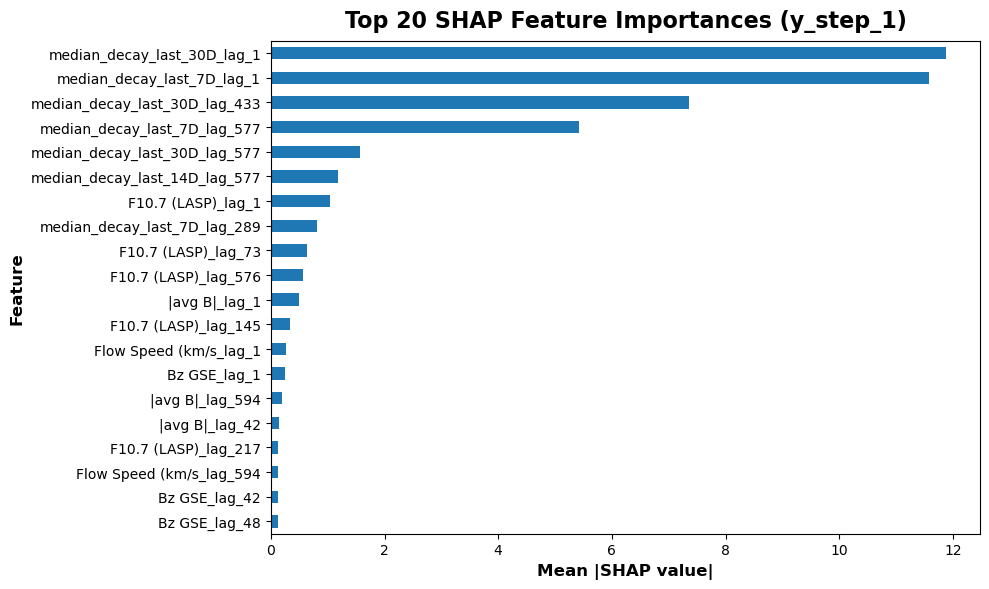

In [17]:
plt.figure(figsize=(10,6))

shap_importance.head(20).sort_values().plot(kind="barh")

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Top 20 SHAP Feature Importances (y_step_1)")
plt.tight_layout()

plt.show()

## Step 8: Group Importance by Physical Feature

In [18]:
groups = [
    "|avg B|",
    "Bz GSE",
    "Temperature (K)",
    "Flow Speed (km/s",
    "F10.7 (LASP)",
    "median_decay_last_7D",
    "median_decay_last_14D",
    "median_decay_last_30D"
]

group_shap = {}

for g in groups:
    cols = [c for c in feature_names if c.startswith(g)]
    if not cols:
        continue
    
    idx = [feature_names.index(c) for c in cols]
    
    group_shap[g] = np.mean(np.abs(shap_values.values[:, idx]))

group_shap = pd.Series(group_shap).sort_values(ascending=False)

print(group_shap)

median_decay_last_30D    4.163609
median_decay_last_7D     3.562005
F10.7 (LASP)             0.407191
median_decay_last_14D    0.246769
Bz GSE                   0.029419
|avg B|                  0.028616
Flow Speed (km/s         0.009382
Temperature (K)          0.001178
dtype: float64


## Grouped SHAP importance for horizons 1-48

In [23]:
feature_names = X_test.columns.tolist()
horizon_names = y_test.columns.tolist()

print("Transformed X shape:", X_trans.shape)
print("Model coef shape:", model.coef_.shape)
print("Number of horizons:", len(horizon_names))

group_to_indices = {}
for g in groups:
    idx = [i for i, c in enumerate(feature_names) if c.startswith(g)]
    if idx:
        group_to_indices[g] = idx

print("Feature groups found:")
for g, idx in group_to_indices.items():
    print(f"  {g}: {len(idx)} columns")

# -------------------------
# sampling for SHAP
# -------------------------
rng = np.random.default_rng(42)

n_background = min(1000, X_trans.shape[0])
background_idx = rng.choice(X_trans.shape[0], n_background, replace=False)
X_background = X_trans[background_idx]

n_explain = min(3000, X_trans.shape[0])
explain_idx = rng.choice(X_trans.shape[0], n_explain, replace=False)
X_explain = X_trans[explain_idx]

print("Background shape:", X_background.shape)
print("Explain shape:", X_explain.shape)

# -------------------------
# wrapper for single-output linear model
# -------------------------
class SingleOutputLinearModel:
    def __init__(self, coef, intercept):
        self.coef_ = np.asarray(coef)
        self.intercept_ = float(intercept)

    def predict(self, X):
        X = np.asarray(X)

# -------------------------
# compute grouped SHAP for all horizons
# -------------------------
group_shap_by_horizon = pd.DataFrame(
    index=group_to_indices.keys(),
    columns=horizon_names,
    dtype=float
)

for horizon_idx, horizon_name in enumerate(horizon_names):
    # print(f"Computing SHAP for {horizon_name} ({horizon_idx+1}/{len(horizon_names)})")

    coef_h = model.coef_[horizon_idx]
    intercept_h = model.intercept_[horizon_idx]

    single_model = SingleOutputLinearModel(coef_h, intercept_h)

    explainer = shap.LinearExplainer(single_model, X_background)
    shap_values = explainer(X_explain)

    shap_abs_mean = np.mean(np.abs(shap_values.values), axis=0)

    for g, idx in group_to_indices.items():
        group_shap_by_horizon.loc[g, horizon_name] = shap_abs_mean[idx].mean()

Transformed X shape: (46224, 538)
Model coef shape: (48, 538)
Number of horizons: 48
Feature groups found:
  |avg B|: 129 columns
  Bz GSE: 129 columns
  Temperature (K): 129 columns
  Flow Speed (km/s: 129 columns
  F10.7 (LASP): 7 columns
  median_decay_last_7D: 5 columns
  median_decay_last_14D: 5 columns
  median_decay_last_30D: 5 columns
Background shape: (1000, 538)
Explain shape: (3000, 538)


Group '|avg B|' SHAP values by horizon:
Min Value = 2.7412e-02 at hour 5.75
Max Value = 2.8931e-02 at hour 9.25
Group 'Bz GSE' SHAP values by horizon:
Min Value = 1.7903e-02 at hour 12.00
Max Value = 2.9047e-02 at hour 0.25
Group 'Temperature (K)' SHAP values by horizon:
Min Value = 8.4410e-04 at hour 2.75
Max Value = 2.6639e-03 at hour 12.00
Group 'Flow Speed (km/s' SHAP values by horizon:
Min Value = 9.2382e-03 at hour 4.25
Max Value = 9.8692e-03 at hour 12.00
Group 'F10.7 (LASP)' SHAP values by horizon:
Min Value = 4.1760e-01 at hour 0.25
Max Value = 4.9296e-01 at hour 12.00
Group 'median_decay_last_7D' SHAP values by horizon:
Min Value = 3.3819e+00 at hour 0.25
Max Value = 3.5144e+00 at hour 12.00
Group 'median_decay_last_14D' SHAP values by horizon:
Min Value = 1.6050e-01 at hour 12.00
Max Value = 2.2909e-01 at hour 0.25
Group 'median_decay_last_30D' SHAP values by horizon:
Min Value = 4.0854e+00 at hour 0.25
Max Value = 4.5971e+00 at hour 12.00


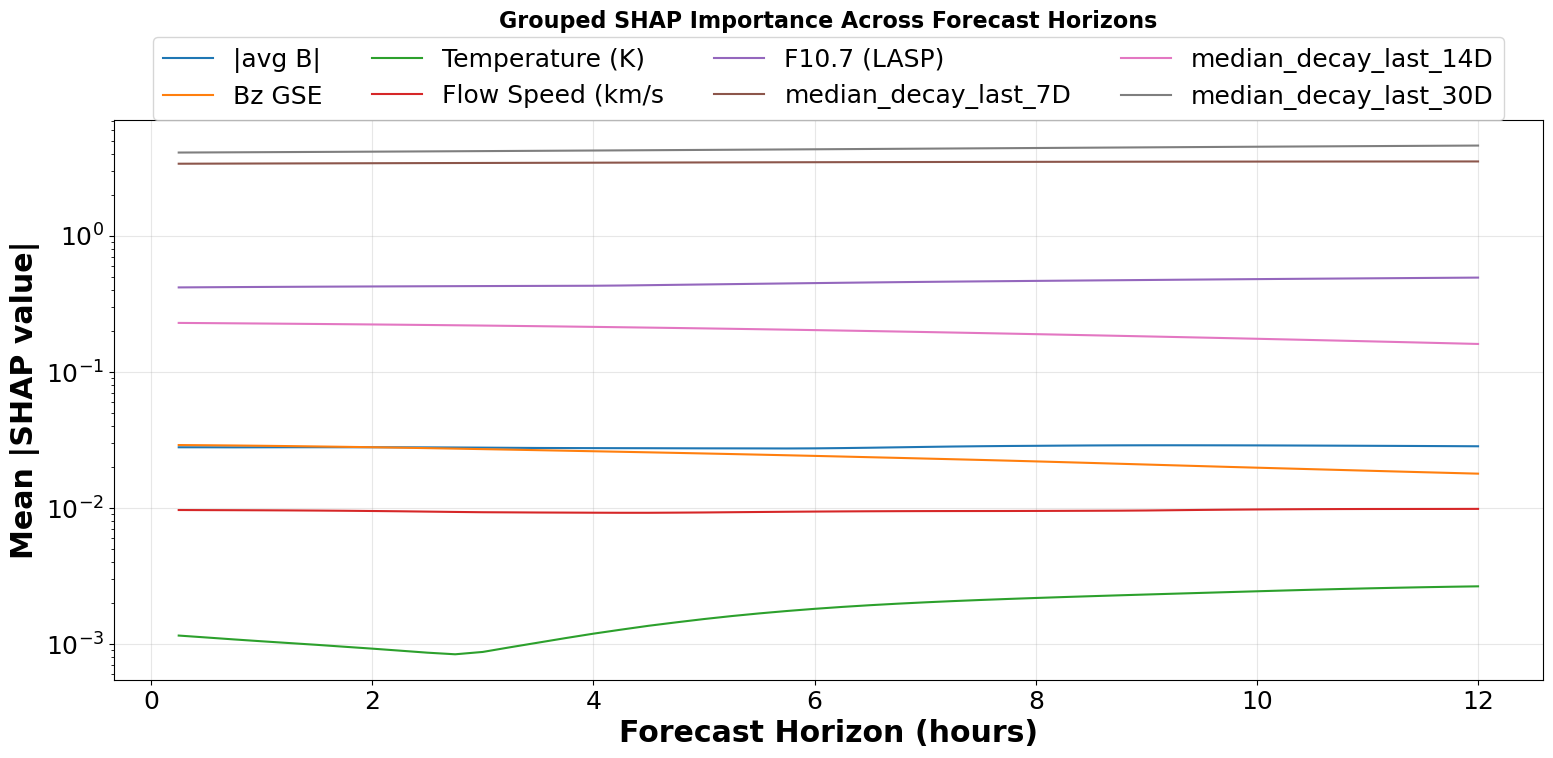


Grouped SHAP importance (first 5 horizons):
                       y_step_1  y_step_2  y_step_3  y_step_4  y_step_5
|avg B|                0.027969  0.027961  0.027934  0.027956  0.027981
Bz GSE                 0.029047  0.028949  0.028828  0.028689  0.028533
Temperature (K)        0.001159  0.001122  0.001085  0.001052  0.001021
Flow Speed (km/s       0.009680  0.009664  0.009652  0.009637  0.009617
F10.7 (LASP)           0.417597  0.418785  0.419866  0.420866  0.421808
median_decay_last_7D   3.381867  3.386045  3.390187  3.394279  3.398315
median_decay_last_14D  0.229094  0.228331  0.227543  0.226732  0.225896
median_decay_last_30D  4.085412  4.093585  4.101941  4.110492  4.119245


In [39]:

# -------------------------
# convert horizon labels to hours
# -------------------------
hours = np.arange(1, len(horizon_names) + 1) / 4.0

# -------------------------
# plot grouped SHAP importance vs forecast horizon
# -------------------------
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(16, 8))

for g in group_shap_by_horizon.index:
    plt.plot(hours, group_shap_by_horizon.loc[g].values, label=g)
    print(f"Group '{g}' SHAP values by horizon:")
    print(f"Min Value = {group_shap_by_horizon.loc[g].values.min():.4e} at hour {hours[group_shap_by_horizon.loc[g].values.argmin()]:.2f}")
    print(f"Max Value = {group_shap_by_horizon.loc[g].values.max():.4e} at hour {hours[group_shap_by_horizon.loc[g].values.argmax()]:.2f}")

plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Mean |SHAP value|")
plt.title("Grouped SHAP Importance Across Forecast Horizons", y=1.14)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol=4)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.yscale('log')  # log scale for better visibility of differences
plt.show()

# -------------------------
# optional: print grouped SHAP table
# -------------------------
print("\nGrouped SHAP importance (first 5 horizons):")
print(group_shap_by_horizon.iloc[:, :5])


## Step 7: SHAP beeswarm / summary plot

## Step 8: dependence plots for key features

## Step 9: aggregate SHAP by physical feature group